In [ ]:
# Create virtual environment 
# create the requirement text in the terminal pip freeze > requirements.txt
# install requirment text: pip install -r requirements.txt


(1) Import Propoerty Data & Load it for Preprocessing 

In [3]:
import pandas as pd
from datetime import datetime
import os

# Specify the path to the saved CSV file
file_path_property = os.path.join('Data', 'properties.csv')

# Load the CSV file into a pandas DataFrame

df = pd.read_csv(file_path_property)
df.head()
df.info()

# print column names as a list 
print(df.columns.tolist())

# Display the first few rows of the DataFrame
print(df.head())

# Print the shape of the resulting training and testing sets for each DataFrame
print("Full Dataset:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75511 entries, 0 to 75510
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              75511 non-null  int64  
 1   price                           75511 non-null  int64  
 2   property_type                   75511 non-null  object 
 3   subproperty_type                75511 non-null  object 
 4   region                          75511 non-null  object 
 5   province                        75511 non-null  object 
 6   locality                        75511 non-null  object 
 7   zip_code                        75511 non-null  int64  
 8   latitude                        61413 non-null  float64
 9   longitude                       61413 non-null  float64
 10  construction_year               42120 non-null  float64
 11  total_area_sqm                  67896 non-null  float64
 12  surface_land_sqm                

(2) Splits the input DataFrame into apartments and houses based on the 'property_type' column, and then further splits each category into training and testing sets.

In [2]:
from sklearn.model_selection import train_test_split

def split_and_split(df):
    """
    Split the dataset into apartments and houses, then split each category into training and testing sets.
    Parameters:
    - df (DataFrame): The input DataFrame containing the dataset.
    Returns:
    - train_apart (DataFrame): Training dataset for apartments.
    - test_apart (DataFrame): Testing dataset for apartments.
    - train_house (DataFrame): Training dataset for houses.
    - test_house (DataFrame): Testing dataset for houses.
    """
    # Split the DataFrame based on the 'property_type' column
    df_apart = df[df['property_type'] == 'APARTMENT']
    df_house = df[df['property_type'] == 'HOUSE']

    # Split df_apart into training and testing sets
    train_apart, test_apart = train_test_split(df_apart, test_size=0.2, random_state=42)

    # Split df_house into training and testing sets
    train_house, test_house = train_test_split(df_house, test_size=0.2, random_state=42)

    # Print the number of observations in each DataFrame
    print("Number of observations in df_apart:", df_apart.shape[0])
    print("Number of observations in df_house:", df_house.shape[0])

    # Print the shape of the resulting training and testing sets for each DataFrame
    print("Training set shape for APARTMENT:", train_apart.shape)
    print("Testing set shape for APARTMENT:", test_apart.shape)
    print("Training set shape for HOUSE:", train_house.shape)
    print("Testing set shape for HOUSE:", test_house.shape)

    return train_apart, test_apart, train_house, test_house

# Assuming df is your input DataFrame return the function
train_apart, test_apart, train_house, test_house = split_and_split(df)

Number of observations in df_apart: 36256
Number of observations in df_house: 39255
Training set shape for APARTMENT: (29004, 30)
Testing set shape for APARTMENT: (7252, 30)
Training set shape for HOUSE: (31404, 30)
Testing set shape for HOUSE: (7851, 30)


(XX) Check the missing values in the training and test dataset

In [ ]:
def count_missing_values(train_apart, train_house, test_apart=None, test_house=None):
    """
    Count the number and percentage of missing values in each column for the training and test dataframes.

    Parameters:
    - train_apart (DataFrame): The training dataframe for apartments.
    - train_house (DataFrame): The training dataframe for houses.
    - test_apart (DataFrame, optional): The test dataframe for apartments. Default is None.
    - test_house (DataFrame, optional): The test dataframe for houses. Default is None.

    Returns:
    - train_apart_missing_info (DataFrame): Missing counts and percentages for the training dataframe for apartments.
    - train_house_missing_info (DataFrame): Missing counts and percentages for the training dataframe for houses.
    - test_apart_missing_info (DataFrame or None): Missing counts and percentages for the test dataframe for apartments,
                                                    or None if test_apart is not provided.
    - test_house_missing_info (DataFrame or None): Missing counts and percentages for the test dataframe for houses,
                                                    or None if test_house is not provided.
    """
    total_train_apart_rows = len(train_apart)
    train_apart_missing_counts = train_apart.isnull().sum()
    train_apart_missing_percentages = (train_apart_missing_counts / total_train_apart_rows) * 100

    train_apart_missing_info = pd.DataFrame({
        'Missing Count': train_apart_missing_counts,
        'Missing Percentage': train_apart_missing_percentages
    })

    total_train_house_rows = len(train_house)
    train_house_missing_counts = train_house.isnull().sum()
    train_house_missing_percentages = (train_house_missing_counts / total_train_house_rows) * 100

    train_house_missing_info = pd.DataFrame({
        'Missing Count': train_house_missing_counts,
        'Missing Percentage': train_house_missing_percentages
    })

    if test_apart is not None:
        total_test_apart_rows = len(test_apart)
        test_apart_missing_counts = test_apart.isnull().sum()
        test_apart_missing_percentages = (test_apart_missing_counts / total_test_apart_rows) * 100

        test_apart_missing_info = pd.DataFrame({
            'Missing Count': test_apart_missing_counts,
            'Missing Percentage': test_apart_missing_percentages
        })

    else:
        test_apart_missing_info = None

    if test_house is not None:
        total_test_house_rows = len(test_house)
        test_house_missing_counts = test_house.isnull().sum()
        test_house_missing_percentages = (test_house_missing_counts / total_test_house_rows) * 100

        test_house_missing_info = pd.DataFrame({
            'Missing Count': test_house_missing_counts,
            'Missing Percentage': test_house_missing_percentages
        })

    else:
        test_house_missing_info = None

    return train_apart_missing_info, train_house_missing_info, test_apart_missing_info, test_house_missing_info

# Example usage:
# Assuming train_apart, train_house, test_apart, and test_house are your dataframes
train_apart_missing_info, train_house_missing_info, test_apart_missing_info, test_house_missing_info = count_missing_values(train_apart, train_house, test_apart, test_house)
print("Missing values in training dataframe for apartments:")
print(train_apart_missing_info)
print("\nMissing values in training dataframe for houses:")
print(train_house_missing_info)
if test_apart_missing_info is not None:
    print("\nMissing values in test dataframe for apartments:")
    print(test_apart_missing_info)
if test_house_missing_info is not None:
    print("\nMissing values in test dataframe for houses:")
    print(test_house_missing_info)


(XX) Check missing for  sqm_feature by fl_features (garden & terrace)

In [ ]:
# check missing terrace sqm and garden sqm if the respective fl_feature is 1/0
# result if fl_feaure is zero then sqm_feature is not missing
import pandas as pd

def count_missing_by_condition(data_set_list, conditional_columns, label_values, target_columns):
    """
    Count the number of missing values for target columns based on the labels of conditional float columns
    in a list of datasets.
    Parameters:
        data_set_list (dict): A dictionary containing the names of datasets as keys and DataFrames as values.
        conditional_columns (dict): A dictionary where keys are target columns and values are conditional float columns.
        label_values (list): List of label values to consider for counting missing values.
        target_columns (list): The names of the target columns for which missing values will be counted.
    Returns:
        dict: A nested dictionary containing the count of missing values for each label value in each dataset
              and for each target column based on the corresponding conditional column.
              Outer keys are dataset names, inner keys are target column names, and values are DataFrames
              representing missing counts for each label value.
    """
    missing_counts = {}

    for data_set_name, df in data_set_list.items():
        missing_counts[data_set_name] = {}

        for target_column in target_columns:
            # Get the corresponding conditional column for the target column
            conditional_column = conditional_columns[target_column]

            # Initialize dictionary to store missing counts for this target column
            missing_counts[data_set_name][target_column] = {}

            for label in label_values:
                # Filter DataFrame based on the conditional column and label value
                filtered_df = df[df[conditional_column] == label]

                # Count missing values in the target column for the filtered DataFrame
                missing_count = filtered_df[target_column].isnull().sum()

                # Store the count in the dictionary
                missing_counts[data_set_name][target_column][f'Missing {target_column} by {conditional_column} = {label}'] = missing_count

    return missing_counts

# Example usage:
# Create a dictionary containing the datasets
data_set_list = {'train_house': train_house, 'test_house': test_house, 'train_apart': train_apart, 'test_apart': test_apart}

# Define conditional float columns, label values, and target columns
conditional_columns = {'garden_sqm': 'fl_garden', 'terrace_sqm': 'fl_terrace'}  # Modify as needed
label_values = [0, 1]  # Modify as needed
target_columns = ['garden_sqm', 'terrace_sqm']  # Modify as needed

# Get missing counts based on conditions
missing_counts = count_missing_by_condition(data_set_list, conditional_columns, label_values, target_columns)

# Print the results
for data_set_name, targets in missing_counts.items():
    print(f"Missing counts for each target column in '{data_set_name}':")
    for target_column, counts in targets.items():
        print(f"Target Column: {target_column}")
        print(pd.DataFrame(counts, index=['Missing Count']))
        print("\n")

(XX) Before Dropping Outliers: Plot price distribution (Histogram and Scatter Plots for the 4 dataframes)
            BACK: after dropping - re-run to see the difference 

In [ ]:
import matplotlib.pyplot as plt

def plot_price_distribution(train_house, test_house, train_apart, test_apart):
    """
    Display histograms and scatter plots for the 'price' variable in the four dataframes.

    Parameters:
    - train_house (DataFrame): Training dataset DataFrame for houses.
    - test_house (DataFrame): Test dataset DataFrame for houses.
    - train_apart (DataFrame): Training dataset DataFrame for apartments.
    - test_apart (DataFrame): Test dataset DataFrame for apartments.

    Returns:
    None. Plots the histograms and scatter plots.
    """
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # Plot histograms
    axs[0, 0].hist(train_house['price'], bins=30, color='blue', alpha=0.7)
    axs[0, 0].set_title(f'Train House (M = {train_house.shape[0]})')
    axs[0, 0].set_xlabel('Price')
    axs[0, 0].set_ylabel('Frequency')

    axs[0, 1].hist(test_house['price'], bins=30, color='green', alpha=0.7)
    axs[0, 1].set_title(f'Test House (M = {test_house.shape[0]})')
    axs[0, 1].set_xlabel('Price')
    axs[0, 1].set_ylabel('Frequency')

    axs[1, 0].hist(train_apart['price'], bins=30, color='red', alpha=0.7)
    axs[1, 0].set_title(f'Train Apartment (M = {train_apart.shape[0]})')
    axs[1, 0].set_xlabel('Price')
    axs[1, 0].set_ylabel('Frequency')

    axs[1, 1].hist(test_apart['price'], bins=30, color='purple', alpha=0.7)
    axs[1, 1].set_title(f'Test Apartment (M = {test_apart.shape[0]})')
    axs[1, 1].set_xlabel('Price')
    axs[1, 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Plot scatter plots with 'id' on the x-axis
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    axs[0, 0].scatter(train_house['id'], train_house['price'], color='blue', alpha=0.7)
    axs[0, 0].set_title('Train House')
    axs[0, 0].set_xlabel('ID')
    axs[0, 0].set_ylabel('Price')

    axs[0, 1].scatter(test_house['id'], test_house['price'], color='green', alpha=0.7)
    axs[0, 1].set_title('Test House')
    axs[0, 1].set_xlabel('ID')
    axs[0, 1].set_ylabel('Price')

    axs[1, 0].scatter(train_apart['id'], train_apart['price'], color='red', alpha=0.7)
    axs[1, 0].set_title('Train Apartment')
    axs[1, 0].set_xlabel('ID')
    axs[1, 0].set_ylabel('Price')

    axs[1, 1].scatter(test_apart['id'], test_apart['price'], color='purple', alpha=0.7)
    axs[1, 1].set_title('Test Apartment')
    axs[1, 1].set_xlabel('ID')
    axs[1, 1].set_ylabel('Price')

    plt.tight_layout()
    plt.show()

# Return the function
plot_price_distribution(train_house, test_house, train_apart, test_apart)


(3) Identify and drop outliers for the price variable using the interquartile range (IQR) and a tolerance level (adjust level between 1.5 & 3).

The tolerance parameter allows you to adjust the sensitivity of outlier detection. A higher tolerance value will result in a wider range of acceptable values, while a lower tolerance value will make the range narrower and thus more restrictive in identifying outliers. Adjusting the tolerance allows you to customize the outlier detection process based on your specific requirements and the characteristics of your data.

(3 linked)A lower tolerance level (e.g., 1.5) results in a more conservative approach, identifying fewer outliers, while a higher tolerance level (e.g., 3) is more lenient and may include more data points within the normal range.

(3) linked : display the IDS dropped and the count for each specific dataframe 

In [3]:
def drop_price_outliers_iqr(df_list, df_ids, tolerance=1):
    """
    Identify and drop outliers for the price variable using the interquartile range (IQR) and a tolerance level.
    Parameters:
    - df_list (dict): Dictionary containing DataFrames to process.
    - df_ids (dict): Dictionary containing the IDs of DataFrames.
    - tolerance (float): Tolerance level for identifying outliers. Default is 2.
    Returns:
    - df_list (dict): Updated dictionary containing DataFrames with outliers dropped.
    """
    for df_type, df in df_list.items():
        q1 = df['price'].quantile(0.25)
        q3 = df['price'].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - tolerance * iqr
        upper_bound = q3 + tolerance * iqr
        # Store IDs of dropped data points
        dropped_ids = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]['id'].tolist()
        # Drop outliers and print their IDs
        df_list[df_type] = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
        if dropped_ids:
            print(f"Dropped IDs for DataFrame {df_ids[df_type]} ({len(dropped_ids)} IDs dropped): {dropped_ids}")
    return df_list
# Call the function for the specific dataframes 
df_list = {
    'train_house': train_house,
    'test_house': test_house,
    'train_apart': train_apart,
    'test_apart': test_apart
}
df_ids = {
    'train_house': 'Train House',
    'test_house': 'Test House',
    'train_apart': 'Train Apartment',
    'test_apart': 'Test Apartment'
}
# Update the df_list with the modified DataFrames
df_list = drop_price_outliers_iqr(df_list, df_ids)


Dropped IDs for DataFrame Train House (3084 IDs dropped): [33483000, 52454000, 68419000, 4052000, 25543000, 1378000, 22557000, 35970000, 42741000, 63464000, 5640000, 40219000, 72627000, 14848000, 9117000, 48589000, 69022000, 38577000, 27073000, 32116000, 74293000, 38390000, 29400000, 43020000, 62585000, 26142000, 45705000, 59686000, 18728000, 55070000, 20964000, 18698000, 49567000, 23804000, 63655000, 14245000, 34735000, 60233000, 39087000, 42167000, 17514000, 66345000, 61332000, 32168000, 32293000, 49543000, 56887000, 59098000, 44899000, 65314000, 60937000, 52790000, 29315000, 21909000, 45760000, 74125000, 24273000, 30888000, 69141000, 35625000, 48758000, 41142000, 64092000, 17689000, 35887000, 43695000, 61682000, 68006000, 70945000, 33164000, 79067000, 29640000, 35031000, 32881000, 15902000, 13135000, 78213000, 1152000, 45091000, 12114000, 42111000, 72079000, 24379000, 16383000, 17528000, 72154000, 41139000, 11447000, 49793000, 5463000, 11705000, 63796000, 43464000, 52054000, 7237100

(XX) After Dropping outliers: Histogram and Scatter Plot for the price 

In [ ]:
import matplotlib.pyplot as plt

def plot_price_distribution(train_house, test_house, train_apart, test_apart):
    """
    Display histograms and scatter plots for the 'price' variable in the four dataframes.

    Parameters:
    - train_house (DataFrame): Training dataset DataFrame for houses.
    - test_house (DataFrame): Test dataset DataFrame for houses.
    - train_apart (DataFrame): Training dataset DataFrame for apartments.
    - test_apart (DataFrame): Test dataset DataFrame for apartments.

    Returns:
    None. Plots the histograms and scatter plots.
    """
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # Plot histograms
    axs[0, 0].hist(train_house['price'], bins=30, color='blue', alpha=0.7)
    axs[0, 0].set_title(f'Train House (M = {train_house.shape[0]})')
    axs[0, 0].set_xlabel('Price')
    axs[0, 0].set_ylabel('Frequency')

    axs[0, 1].hist(test_house['price'], bins=30, color='green', alpha=0.7)
    axs[0, 1].set_title(f'Test House (M = {test_house.shape[0]})')
    axs[0, 1].set_xlabel('Price')
    axs[0, 1].set_ylabel('Frequency')

    axs[1, 0].hist(train_apart['price'], bins=30, color='red', alpha=0.7)
    axs[1, 0].set_title(f'Train Apartment (M = {train_apart.shape[0]})')
    axs[1, 0].set_xlabel('Price')
    axs[1, 0].set_ylabel('Frequency')

    axs[1, 1].hist(test_apart['price'], bins=30, color='purple', alpha=0.7)
    axs[1, 1].set_title(f'Test Apartment (M = {test_apart.shape[0]})')
    axs[1, 1].set_xlabel('Price')
    axs[1, 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Plot scatter plots with 'id' on the x-axis
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    axs[0, 0].scatter(train_house['id'], train_house['price'], color='blue', alpha=0.7)
    axs[0, 0].set_title('Train House')
    axs[0, 0].set_xlabel('ID')
    axs[0, 0].set_ylabel('Price')

    axs[0, 1].scatter(test_house['id'], test_house['price'], color='green', alpha=0.7)
    axs[0, 1].set_title('Test House')
    axs[0, 1].set_xlabel('ID')
    axs[0, 1].set_ylabel('Price')

    axs[1, 0].scatter(train_apart['id'], train_apart['price'], color='red', alpha=0.7)
    axs[1, 0].set_title('Train Apartment')
    axs[1, 0].set_xlabel('ID')
    axs[1, 0].set_ylabel('Price')

    axs[1, 1].scatter(test_apart['id'], test_apart['price'], color='purple', alpha=0.7)
    axs[1, 1].set_title('Test Apartment')
    axs[1, 1].set_xlabel('ID')
    axs[1, 1].set_ylabel('Price')

    plt.tight_layout()
    plt.show()

# Return the function
plot_price_distribution(train_house, test_house, train_apart, test_apart)

(XX) Drop Columns with missing values > 45% as per specific data frames. Columns to drop for ALL DATA FRAME [ cadastral_income (all dataframes) + construction_year] 
for APARTMENT Dataframe alone columns to drop [surface_land_sqm, nbr_frontages ]

In [22]:
def drop_columns(df_list):
    """
    Drop specified columns from the provided dataframes.
    Parameters:
    - df_list (dict): Dictionary containing DataFrames to process.
    Returns:
    - df_list (dict): Updated dictionary containing DataFrames with specified columns dropped.
    """
    columns_to_drop = ['cadastral_income', 'construction_year']
    apart_columns_to_drop = ['surface_land_sqm', 'nbr_frontages']
    for df_type, df in df_list.items():
        # Drop specified columns
        df_list[df_type] = df.drop(columns=columns_to_drop, errors='ignore')   
        # Drop additional columns for apartment dataframes
        if 'apart' in df_type:
            df_list[df_type] = df_list[df_type].drop(columns=apart_columns_to_drop, errors='ignore')
    return df_list

# Assuming train_house, test_house, train_apart, and test_apart are your DataFrames
df_list = {'train_house': train_house, 'test_house': test_house, 'train_apart': train_apart, 'test_apart': test_apart}

# Call the function and update df_list with modified dataframes
df_list = drop_columns(df_list)
# Displaying shape and head(10) of each DataFrame in df_list
for df_type, df in df_list.items():
    print(f"DataFrame: {df_type}")
    print(f"Shape: {df.shape}")
    print(df.head(10))
    print()
# Call the drop_columns function
df_list = drop_columns(df_list)

# Display the head and shape of each DataFrame in df_list
for df_type, df in df_list.items():
    print(f"DataFrame: {df_type}")
    print("Head:")
    print(df.head(10))  # Displaying the first 10 rows
    print("Shape:")
    print(df.shape)
    print()


DataFrame: train_house
Shape: (31404, 28)
             id   price property_type    subproperty_type    region  \
72526  31625000  390000         HOUSE               VILLA  Wallonia   
54182   9243000  425062         HOUSE               HOUSE  Wallonia   
33479  28091000  275000         HOUSE               HOUSE  Wallonia   
2401   12026000  305000         HOUSE               HOUSE  Flanders   
47804   3829000  500000         HOUSE               HOUSE  Flanders   
723    66426000  425000         HOUSE           FARMHOUSE  Wallonia   
75151   3353000  549000         HOUSE  MIXED_USE_BUILDING  Flanders   
62477   9622000  379000         HOUSE               HOUSE  Flanders   
2118   75226000  169000         HOUSE               HOUSE  Wallonia   
61761  39623000  110000         HOUSE               HOUSE  Wallonia   

              province     locality  zip_code   latitude  longitude  ...  \
72526            Namur        Namur      5100        NaN        NaN  ...   
54182  Walloon Brabant  

(include this) Dropping rows (data points) if region , province , locality  are missing (including the ones labelled as MISSING)          

In [4]:
import numpy as np

def drop_missing_rows(df_list, columns):
    """
    Drop rows from the provided dataframes if the specified columns have missing values.
    
    Parameters:
    - df_list (dict): Dictionary containing DataFrames to process.
    - columns (list of str): List of column names to check for missing values.
    
    Returns:
    - df_list (dict): Updated dictionary containing DataFrames with missing rows dropped.
    """
    for df_type, df in df_list.items():
        # Drop rows with missing values in specified columns
        df_list[df_type] = df.dropna(subset=columns)
        # Replace 'MISSING' with np.nan before dropping
        df_list[df_type].replace('MISSING', np.nan, inplace=True)
        df_list[df_type] = df_list[df_type].dropna(subset=columns)
        
    return df_list


(6) Encode the cat_features using OneHotEncoder

In [72]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

def encode_categorical_features(df_list):
    """
    Encode categorical features using one-hot encoding.

    Parameters:
    - df_list (dict): Dictionary containing DataFrames to process.

    Returns:
    - df_list (dict): Updated dictionary containing DataFrames with categorical features encoded and concatenated.
    - cat_features (list): List of encoded categorical feature names.
    """
    # Define the categorical features to encode
    cat_features = ['property_type', 'subproperty_type', 'region', 'province', 'locality', 
                    'equipped_kitchen', 'state_building', 'epc', 'heating_type']

    # Initialize an empty list to store the encoded column names
    encoded_columns = []

    for df_type, df in df_list.items():
        # Initialize the OneHotEncoder
        encoder = OneHotEncoder(sparse=False)

        # Fit and transform the categorical features
        encoded_features = encoder.fit_transform(df[cat_features])
        
        # Get the names of the encoded columns
        encoded_column_names = encoder.get_feature_names_out(cat_features)
        encoded_columns.extend(encoded_column_names)

        # Convert the encoded features to a DataFrame
        encoded_df = pd.DataFrame(encoded_features, columns=encoded_column_names)
        
        # Drop the original categorical features from the DataFrame
        df = df.drop(columns=cat_features)
        
        # Concatenate the encoded features with the original DataFrame
        df_list[df_type] = pd.concat([df, encoded_df], axis=1)

    return df_list, encoded_columns

# Assuming train_house, test_house, train_apart, and test_apart are your DataFrames
df_list = {
    'train_house': train_house,
    'test_house': test_house,
    'train_apart': train_apart,
    'test_apart': test_apart
}

# Encode categorical features and store the list of encoded column names
df_list, encoded_columns = encode_categorical_features(df_list)

# Display the updated DataFrame heads
for df_type, df in df_list.items():
    print(f"DataFrame: {df_type}")
    print(df.head())
    print()

# Use encoded_columns later in the regression model
print("List of encoded column names:")
print(encoded_columns)


/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


DataFrame: train_house
               id     price  zip_code   latitude  longitude  \
72526  31625000.0  390000.0    5100.0        NaN        NaN   
54182   9243000.0  425062.0    1450.0  50.586120   4.644111   
33479  28091000.0  275000.0    6927.0  50.084308   5.230460   
2401   12026000.0  305000.0    2620.0  51.143888   4.340448   
47804   3829000.0  500000.0    9700.0  50.856324   3.630965   

       construction_year  total_area_sqm  surface_land_sqm  nbr_frontages  \
72526             1976.0           225.0            1509.0            3.0   
54182                NaN           193.0             690.0            2.0   
33479             2006.0           106.0            1031.0            4.0   
2401              1918.0           126.0             250.0            3.0   
47804                NaN           350.0             420.0            3.0   

       nbr_bedrooms  ...  epc_G  epc_MISSING  heating_type_CARBON  \
72526           4.0  ...    NaN          NaN                  NaN 

/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


(xx) Encode Categorical Features Using OneHot Econding & stored the encoded columns in a list called cat_feature
List of encoded categorical features:
['property_type', 'subproperty_type', 'region', 'province', 'locality', 'equipped_kitchen', 'state_building', 'epc', 'heating_type']

In [45]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np

def encode_categorical_features(df_list):
    """
    Encode categorical features using one-hot encoding.

    Parameters:
    - df_list (dict): Dictionary containing DataFrames to process.

    Returns:
    - df_list (dict): Updated dictionary containing DataFrames with categorical features encoded.
    - cat_features (list): List of encoded categorical feature names.
    """
    # Define the categorical features to encode
    cat_features = ['property_type', 'subproperty_type', 'region', 'province', 'locality', 
                    'equipped_kitchen', 'state_building', 'epc', 'heating_type']

    # Initialize the OneHotEncoder
    encoder = OneHotEncoder()

    for df_type, df in df_list.items():
        # Fit and transform the categorical features
        encoded_features = encoder.fit_transform(df[cat_features])
        
        # Convert the encoded features to a DataFrame
        encoded_df = pd.DataFrame(encoded_features.toarray(), columns=encoder.get_feature_names_out(cat_features))
        
        # Concatenate the encoded features with the original DataFrame
        df_list[df_type] = pd.concat([df.drop(columns=cat_features), encoded_df], axis=1)

    return df_list, cat_features

# Assuming train_house, test_house, train_apart, and test_apart are your DataFrames
df_list = {
    'train_house': train_house,
    'test_house': test_house,
    'train_apart': train_apart,
    'test_apart': test_apart
}

# Encode categorical features and store the list of encoded categorical feature names
df_list, cat_features = encode_categorical_features(df_list)

# Display the updated DataFrame heads
for df_type, df in df_list.items():
    print(f"DataFrame: {df_type}")
    print(df.head())
    print()

# Use cat_features later in the regression model
print("List of encoded categorical features:")
print(cat_features)


DataFrame: train_house
               id     price  zip_code   latitude  longitude  \
72526  31625000.0  390000.0    5100.0        NaN        NaN   
54182   9243000.0  425062.0    1450.0  50.586120   4.644111   
33479  28091000.0  275000.0    6927.0  50.084308   5.230460   
2401   12026000.0  305000.0    2620.0  51.143888   4.340448   
47804   3829000.0  500000.0    9700.0  50.856324   3.630965   

       construction_year  total_area_sqm  surface_land_sqm  nbr_frontages  \
72526             1976.0           225.0            1509.0            3.0   
54182                NaN           193.0             690.0            2.0   
33479             2006.0           106.0            1031.0            4.0   
2401              1918.0           126.0             250.0            3.0   
47804                NaN           350.0             420.0            3.0   

       nbr_bedrooms  ...  epc_G  epc_MISSING  heating_type_CARBON  \
72526           4.0  ...    NaN          NaN                  NaN 

(5) Scale the num_features

In [5]:
from sklearn.preprocessing import MinMaxScaler

def scale_numerical_features(dataframes, num_features):
    scaler = MinMaxScaler()
    scaled_dataframes = []

    for df_name, df in dataframes.items():
        df_scaled = df.copy()
        df_scaled[num_features] = scaler.fit_transform(df[num_features])
        scaled_dataframes.append(df_scaled)
        print(f"Scaling successful for dataframe: {df_name}")

    return scaled_dataframes

# List of dataframes
df_list = {
    'train_house': train_house,
    'test_house': test_house,
    'train_apart': train_apart,
    'test_apart': test_apart
}

# Numerical features to scale
num_features_to_scale = ["total_area_sqm", "surface_land_sqm", "nbr_frontages", 
                         "nbr_bedrooms", "terrace_sqm", "garden_sqm", 
                         "primary_energy_consumption_sqm", "cadastral_income"]

# Scale numerical features for each dataframe in the list
scaled_dfs = scale_numerical_features(df_list, num_features_to_scale)


Scaling successful for dataframe: train_house
Scaling successful for dataframe: test_house
Scaling successful for dataframe: train_apart
Scaling successful for dataframe: test_apart


/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:479: RuntimeWarning: All-NaN slice encountered
  data_min = np.nanmin(X, axis=0)
/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:480: RuntimeWarning: All-NaN slice encountered
  data_max = np.nanmax(X, axis=0)
/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:479: RuntimeWarning: All-NaN slice encountered
  data_min = np.nanmin(X, axis=0)
/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:480: RuntimeWarning: All-NaN slice encountered
  data_max = np.nanmax(X, axis=0)


(7) Impute  missing values using SimpleImputer

In [6]:
from sklearn.impute import SimpleImputer
import numpy as np

def impute_num(df, num_features):
    num_imputer = SimpleImputer(strategy='median')
    missing_mask = df[num_features].isnull().values
    if np.any(missing_mask):
        num_imputed_values = num_imputer.fit_transform(df[num_features])
        for i, feature in enumerate(num_features):
            if np.any(missing_mask[:, i]):
                df[feature] = num_imputed_values[:, i]
                print("Numeric feature '{}' imputed successfully.".format(feature))


def impute_cat(df, cat_features):
    cat_missing_mask = df[cat_features].isnull().values
    if np.any(cat_missing_mask):
        cat_imputer = SimpleImputer(strategy='most_frequent')
        cat_imputed_values = cat_imputer.fit_transform(df[cat_features])
        df[cat_features] = cat_imputed_values
        print("Categorical features imputed successfully.")

def impute_missing_values(df_list):
    imputed_columns = []
    missing_counts = []

    num_features = ["total_area_sqm", "nbr_frontages", "nbr_bedrooms", "terrace_sqm",
                    "garden_sqm", "primary_energy_consumption_sqm", "cadastral_income"]
    fl_features = ["fl_furnished", "fl_open_fire", "fl_terrace", "fl_garden", "fl_swimming_pool", "fl_floodzone",
                   "fl_double_glazing"]
    cat_features = ["subproperty_type", "region", "province", "locality", "equipped_kitchen","state_building", "epc", "heating_type"]

    for df in df_list:
        # Identify columns with missing values
        missing_counts.append(df.isnull().sum())

        # Impute missing values for numeric features
        impute_num(df, num_features)

        # Impute missing values for categorical features
        impute_cat(df, cat_features)

        # Record the names of imputed columns
        imputed_columns.extend(num_features)
        imputed_columns.extend(cat_features)
        imputed_columns.extend(fl_features)

    # Rename the dataframes and return them along with imputed columns and missing counts
    train_2_house, test_2_house, train_2_apart, test_2_apart = df_list
    return (train_2_house, test_2_house, train_2_apart, test_2_apart), imputed_columns, missing_counts

# Call the function
# Assuming train_house, test_house, train_apart, and test_apart are your DataFrames
df_list = [train_house, test_house, train_apart, test_apart]
result, imputed_columns, missing_counts = impute_missing_values(df_list)

# Print the result and verify the output
print("Result:", result)
print("Imputed Columns:", imputed_columns)
print("Missing Counts:", missing_counts)
imputed_columns_unique = list(set(imputed_columns))
print("Imputed Columns:", imputed_columns_unique)

Numeric feature 'total_area_sqm' imputed successfully.
Numeric feature 'nbr_frontages' imputed successfully.
Numeric feature 'terrace_sqm' imputed successfully.
Numeric feature 'garden_sqm' imputed successfully.
Numeric feature 'primary_energy_consumption_sqm' imputed successfully.
Numeric feature 'cadastral_income' imputed successfully.
Numeric feature 'total_area_sqm' imputed successfully.
Numeric feature 'nbr_frontages' imputed successfully.
Numeric feature 'terrace_sqm' imputed successfully.
Numeric feature 'garden_sqm' imputed successfully.
Numeric feature 'primary_energy_consumption_sqm' imputed successfully.
Numeric feature 'cadastral_income' imputed successfully.
Numeric feature 'total_area_sqm' imputed successfully.
Numeric feature 'nbr_frontages' imputed successfully.
Numeric feature 'terrace_sqm' imputed successfully.
Numeric feature 'garden_sqm' imputed successfully.
Numeric feature 'primary_energy_consumption_sqm' imputed successfully.
Numeric feature 'cadastral_income' im

In [20]:
# Calculate the number of missing observations in each column for each DataFrame
missing_train_house_columns = train_house.isnull().sum()
missing_test_house_columns = test_house.isnull().sum()
missing_train_apart_columns = train_apart.isnull().sum()
missing_test_apart_columns = test_apart.isnull().sum()

# Print the results
print("Number of missing observations in each column for train_house DataFrame:")
print(missing_train_house_columns)
print("\nNumber of missing observations in each column for test_house DataFrame:")
print(missing_test_house_columns)
print("\nNumber of missing observations in each column for train_apart DataFrame:")
print(missing_train_apart_columns)
print("\nNumber of missing observations in each column for test_apart DataFrame:")
print(missing_test_apart_columns)



Number of missing observations in each column for train_house DataFrame:
id                                    0
price                                 0
property_type                         0
subproperty_type                      0
region                                0
province                              0
locality                              0
zip_code                              0
latitude                           6567
longitude                          6567
construction_year                 14706
total_area_sqm                        0
surface_land_sqm                      0
nbr_frontages                         0
nbr_bedrooms                          0
equipped_kitchen                      0
fl_furnished                          0
fl_open_fire                          0
fl_terrace                            0
terrace_sqm                           0
fl_garden                             0
garden_sqm                            0
fl_swimming_pool                      0
fl_floo

LAST LR

In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Assuming df_list is your list of dataframes containing train and test data
df_list = [train_house, test_house, train_apart, test_apart]

# Features
num_features = ["total_area_sqm", "nbr_frontages", "nbr_bedrooms", "terrace_sqm",
                "garden_sqm", "primary_energy_consumption_sqm", "cadastral_income"]
fl_features = ["fl_furnished", "fl_open_fire", "fl_terrace", "fl_garden", "fl_swimming_pool", "fl_floodzone",
               "fl_double_glazing"]
cat_features = ["subproperty_type", "region", "province", "locality", "equipped_kitchen",
                "state_building", "epc", "heating_type"]

# Categorical features to be one-hot encoded
cat_features_to_encode = cat_features

# Apply OneHotEncoder to categorical features
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(df_list[0][cat_features_to_encode])

# Get the unique categories for each feature
categories = encoder.categories_

# Create feature names for one-hot encoded features
feature_names = []
for i, cat_feature in enumerate(cat_features_to_encode):
    for category in categories[i]:
        feature_names.append(f"{cat_feature}_{category}")

# Create new dataframes with one-hot encoded categorical features
train_house_encoded = pd.DataFrame(encoded_features, columns=feature_names, index=df_list[0].index)
test_house_encoded = pd.DataFrame(encoder.transform(df_list[1][cat_features_to_encode]), columns=feature_names, index=df_list[1].index)
train_apart_encoded = pd.DataFrame(encoder.transform(df_list[2][cat_features_to_encode]), columns=feature_names, index=df_list[2].index)
test_apart_encoded = pd.DataFrame(encoder.transform(df_list[3][cat_features_to_encode]), columns=feature_names, index=df_list[3].index)

# Concatenate one-hot encoded features with original numerical and boolean features
X_train_house_encoded = pd.concat([df_list[0][num_features + fl_features], train_house_encoded], axis=1)
X_test_house_encoded = pd.concat([df_list[1][num_features + fl_features], test_house_encoded], axis=1)
X_train_apart_encoded = pd.concat([df_list[2][num_features + fl_features], train_apart_encoded], axis=1)
X_test_apart_encoded = pd.concat([df_list[3][num_features + fl_features], test_apart_encoded], axis=1)

# Define the target variables
y_train_house = df_list[0]["price"]
y_train_apart = df_list[2]["price"]

# Train linear regression models for houses and apartments
model_house_linear = LinearRegression()
model_house_linear.fit(X_train_house_encoded, y_train_house)

model_apart_linear = LinearRegression()
model_apart_linear.fit(X_train_apart_encoded, y_train_apart)

# Predict on the training and testing sets for houses
y_train_pred_house_linear = model_house_linear.predict(X_train_house_encoded)
y_test_pred_house_linear = model_house_linear.predict(X_test_house_encoded)

# Predict on the training and testing sets for apartments
y_train_pred_apart_linear = model_apart_linear.predict(X_train_apart_encoded)
y_test_pred_apart_linear = model_apart_linear.predict(X_test_apart_encoded)

# Evaluate the linear regression models for houses
train_r2_house_linear = r2_score(y_train_house, y_train_pred_house_linear)
test_r2_house_linear = r2_score(y_test_house, y_test_pred_house_linear)

# Evaluate the linear regression models for apartments
train_r2_apart_linear = r2_score(y_train_apart, y_train_pred_apart_linear)
test_r2_apart_linear = r2_score(y_test_apart, y_test_pred_apart_linear)

# Print R-squared scores for linear regression
print("R-squared score for houses (Linear Regression) - Train:", train_r2_house_linear)
print("R-squared score for houses (Linear Regression) - Test:", test_r2_house_linear)
print("R-squared score for apartments (Linear Regression) - Train:", train_r2_apart_linear)
print("R-squared score for apartments (Linear Regression) - Test:", test_r2_apart_linear)


# Define the number of folds for cross-validation
num_folds = 5

# Define your data and target variables for linear regression
X_linear = X_train_house_encoded
y_linear = y_train_house

# Cross-validation
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Perform cross-validation for linear regression
linear_scores = cross_val_score(model_house_linear, X_linear, y_linear, cv=kf)

# Print cross-validation scores
print("Linear Regression Cross-Validation Scores:", linear_scores)

/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


NameError: name 'y_test_house' is not defined

In [98]:
# (8) both models 
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np

# Assuming df_list is your list of dataframes containing train and test data
# df_list = [train_house, test_house, train_apart, test_apart]

# Categorical features to be one-hot encoded
cat_features_to_encode = ["subproperty_type", "region", "province", "locality", "equipped_kitchen", "state_building", "epc", "heating_type"]

# Apply OneHotEncoder to categorical features
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(df_list[0][cat_features_to_encode])

# Get the unique categories for each feature
categories = encoder.categories_

# Create feature names for one-hot encoded features
feature_names = []
for i, cat_feature in enumerate(cat_features_to_encode):
    for category in categories[i]:
        feature_names.append(f"{cat_feature}_{category}")

# Create new dataframes with one-hot encoded categorical features
train_house_encoded = pd.DataFrame(encoded_features, columns=feature_names, index=df_list[0].index)
test_house_encoded = pd.DataFrame(encoder.transform(df_list[1][cat_features_to_encode]), columns=feature_names, index=df_list[1].index)
train_apart_encoded = pd.DataFrame(encoder.transform(df_list[2][cat_features_to_encode]), columns=feature_names, index=df_list[2].index)
test_apart_encoded = pd.DataFrame(encoder.transform(df_list[3][cat_features_to_encode]), columns=feature_names, index=df_list[3].index)

# Concatenate one-hot encoded features with original numerical and boolean features
X_train_house_encoded = pd.concat([train_house[num_features + fl_features], train_house_encoded], axis=1)
X_test_house_encoded = pd.concat([test_house[num_features + fl_features], test_house_encoded], axis=1)
X_train_apart_encoded = pd.concat([train_apart[num_features + fl_features], train_apart_encoded], axis=1)
X_test_apart_encoded = pd.concat([test_apart[num_features + fl_features], test_apart_encoded], axis=1)

# Train linear regression models for houses and apartments
model_house = LinearRegression()
model_house.fit(X_train_house_encoded, y_train_house)

model_apart = LinearRegression()
model_apart.fit(X_train_apart_encoded, y_train_apart)

# Predict on the training and testing sets for houses
y_train_pred_house = model_house.predict(X_train_house_encoded)
y_test_pred_house = model_house.predict(X_test_house_encoded)

# Predict on the training and testing sets for apartments
y_train_pred_apart = model_apart.predict(X_train_apart_encoded)
y_test_pred_apart = model_apart.predict(X_test_apart_encoded)

# Evaluate the models for houses
train_r2_house = r2_score(y_train_house, y_train_pred_house)
test_r2_house = r2_score(y_test_house, y_test_pred_house)

# Evaluate the models for apartments
train_r2_apart = r2_score(y_train_apart, y_train_pred_apart)
test_r2_apart = r2_score(y_test_apart, y_test_pred_apart)

# Print R-squared scores
print("R-squared score for houses - Train:", train_r2_house)
print("R-squared score for houses - Test:", test_r2_house)
print("R-squared score for apartments - Train:", train_r2_apart)
print("R-squared score for apartments - Test:", test_r2_apart)


# Define the RandomForest model
random_forest_model = RandomForestRegressor()

# Define the number of folds for cross-validation
num_folds = 5

# Define the number of bootstrapping iterations
num_iterations = 100

# Define your data and target variables
X = X_train_house_encoded  # Replace X_train_house_encoded with your actual feature matrix
y = y_train_house  # Replace y_train_house with your actual target variable

# Cross-validation
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Perform cross-validation for linear regression
linear_scores = cross_val_score(model_house, X, y, cv=kf)

# Perform cross-validation for RandomForest
rf_scores = cross_val_score(random_forest_model, X, y, cv=kf)

# Bootstrapping
linear_bootstrap_scores = []
rf_bootstrap_scores = []

for _ in range(num_iterations):
    # Generate random indices with replacement for bootstrapping
    indices = np.random.choice(len(X), len(X), replace=True)
    X_bootstrap = X.iloc[indices]
    y_bootstrap = y.iloc[indices]
    
    # Calculate scores for linear regression
    model_house.fit(X_bootstrap, y_bootstrap)
    linear_bootstrap_score = model_house.score(X_bootstrap, y_bootstrap)
    linear_bootstrap_scores.append(linear_bootstrap_score)
    
    # Calculate scores for RandomForest
    random_forest_model.fit(X_bootstrap, y_bootstrap)
    rf_bootstrap_score = random_forest_model.score(X_bootstrap, y_bootstrap)
    rf_bootstrap_scores.append(rf_bootstrap_score)

# Print results
print("Linear Regression Cross-Validation Scores:", linear_scores)
print("RandomForest Cross-Validation Scores:", rf_scores)
print("Linear Regression Bootstrapping Scores:", linear_bootstrap_scores)
print("RandomForest Bootstrapping Scores:", rf_bootstrap_scores)


/Users/ARahim/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


R-squared score for houses - Train: 0.4041791491742732
R-squared score for houses - Test: 0.43004976529476713
R-squared score for apartments - Train: 0.3253320543133873
R-squared score for apartments - Test: -1.7544933573066026


(8) Model training using linear regression 

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Assuming df_list is your list of dataframes containing train and test data
# df_list = [train_house, test_house, train_apart, test_apart]

# Categorical features to be one-hot encoded
cat_features_to_encode = ["subproperty_type", "region", "province", "locality", "equipped_kitchen","state_building", "epc", "heating_type"]

# Apply OneHotEncoder to categorical features
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(df_list[0][cat_features_to_encode])

# Get the unique categories for each feature
categories = encoder.categories_

# Create feature names for one-hot encoded features
feature_names = []
for i, cat_feature in enumerate(cat_features_to_encode):
    for category in categories[i]:
        feature_names.append(f"{cat_feature}_{category}")

# Create new dataframes with one-hot encoded categorical features
train_house_encoded = pd.DataFrame(encoded_features, columns=feature_names, index=df_list[0].index)
test_house_encoded = pd.DataFrame(encoder.transform(df_list[1][cat_features_to_encode]), columns=feature_names, index=df_list[1].index)
train_apart_encoded = pd.DataFrame(encoder.transform(df_list[2][cat_features_to_encode]), columns=feature_names, index=df_list[2].index)
test_apart_encoded = pd.DataFrame(encoder.transform(df_list[3][cat_features_to_encode]), columns=feature_names, index=df_list[3].index)

# Concatenate one-hot encoded features with original numerical and boolean features
X_train_house_encoded = pd.concat([train_house[num_features + fl_features], train_house_encoded], axis=1)
X_test_house_encoded = pd.concat([test_house[num_features + fl_features], test_house_encoded], axis=1)
X_train_apart_encoded = pd.concat([train_apart[num_features + fl_features], train_apart_encoded], axis=1)
X_test_apart_encoded = pd.concat([test_apart[num_features + fl_features], test_apart_encoded], axis=1)

# Train linear regression models for houses and apartments
model_house = LinearRegression()
model_house.fit(X_train_house_encoded, y_train_house)

model_apart = LinearRegression()
model_apart.fit(X_train_apart_encoded, y_train_apart)

# Predict on the training and testing sets for houses
y_train_pred_house = model_house.predict(X_train_house_encoded)
y_test_pred_house = model_house.predict(X_test_house_encoded)

# Predict on the training and testing sets for apartments
y_train_pred_apart = model_apart.predict(X_train_apart_encoded)
y_test_pred_apart = model_apart.predict(X_test_apart_encoded)

# Evaluate the models for houses
train_r2_house = r2_score(y_train_house, y_train_pred_house)
test_r2_house = r2_score(y_test_house, y_test_pred_house)

# Evaluate the models for apartments
train_r2_apart = r2_score(y_train_apart, y_train_pred_apart)
test_r2_apart = r2_score(y_test_apart, y_test_pred_apart)

# Print R-squared scores
print("R-squared score for houses - Train:", train_r2_house)
print("R-squared score for houses - Test:", test_r2_house)
print("R-squared score for apartments - Train:", train_r2_apart)
print("R-squared score for apartments - Test:", test_r2_apart)


# Define the RandomForest model
random_forest_model = RandomForestRegressor()

# Define the number of folds for cross-validation
num_folds = 5

# Define the number of bootstrapping iterations
num_iterations = 100

# Define your data and target variables
X = your_data
y = your_target

# Cross-validation
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Perform cross-validation for linear regression
linear_scores = cross_val_score(linear_model, X, y, cv=kf)

# Perform cross-validation for RandomForest
rf_scores = cross_val_score(random_forest_model, X, y, cv=kf)

# Bootstrapping
linear_bootstrap_scores = []
rf_bootstrap_scores = []

for _ in range(num_iterations):
    # Generate random indices with replacement for bootstrapping
    indices = np.random.choice(len(X), len(X), replace=True)
    X_bootstrap = X[indices]
    y_bootstrap = y[indices]
    
    # Calculate scores for linear regression
    linear_bootstrap_score = linear_model.fit(X_bootstrap, y_bootstrap).score(X_bootstrap, y_bootstrap)
    linear_bootstrap_scores.append(linear_bootstrap_score)
    
    # Calculate scores for RandomForest
    rf_bootstrap_score = random_forest_model.fit(X_bootstrap, y_bootstrap).score(X_bootstrap, y_bootstrap)
    rf_bootstrap_scores.append(rf_bootstrap_score)

# Print results
print("Linear Regression Cross-Validation Scores:", linear_scores)
print("RandomForest Cross-Validation Scores:", rf_scores)
print("Linear Regression Bootstrapping Scores:", linear_bootstrap_scores)
print("RandomForest Bootstrapping Scores:", rf_bootstrap_scores)

(9) Experiement with RandomForest Model

In [95]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Train Random Forest models for houses and apartments
model_house_rf = RandomForestRegressor()
model_house_rf.fit(X_train_house_encoded, y_train_house)

model_apart_rf = RandomForestRegressor()
model_apart_rf.fit(X_train_apart_encoded, y_train_apart)

# Predict on the training and testing sets for houses using Random Forest
y_train_pred_house_rf = model_house_rf.predict(X_train_house_encoded)
y_test_pred_house_rf = model_house_rf.predict(X_test_house_encoded)

# Predict on the training and testing sets for apartments using Random Forest
y_train_pred_apart_rf = model_apart_rf.predict(X_train_apart_encoded)
y_test_pred_apart_rf = model_apart_rf.predict(X_test_apart_encoded)

# Evaluate the models for houses using Random Forest
train_r2_house_rf = r2_score(y_train_house, y_train_pred_house_rf)
test_r2_house_rf = r2_score(y_test_house, y_test_pred_house_rf)

# Evaluate the models for apartments using Random Forest
train_r2_apart_rf = r2_score(y_train_apart, y_train_pred_apart_rf)
test_r2_apart_rf = r2_score(y_test_apart, y_test_pred_apart_rf)

# Print R-squared scores for Random Forest
print("R-squared score for houses (Random Forest) - Train:", train_r2_house_rf)
print("R-squared score for houses (Random Forest) - Test:", test_r2_house_rf)
print("R-squared score for apartments (Random Forest) - Train:", train_r2_apart_rf)
print("R-squared score for apartments (Random Forest) - Test:", test_r2_apart_rf)



R-squared score for houses (Random Forest) - Train: 0.9432878356230457
R-squared score for houses (Random Forest) - Test: 0.6347048681690719
R-squared score for apartments (Random Forest) - Train: 0.9533626255007825
R-squared score for apartments (Random Forest) - Test: 0.6970396475597187


Experiementing with the model 

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def train_and_evaluate(dataframes, num_features, fl_features, cat_features, target='price'):
    for df_name, df in dataframes.items():
        # Prepare features and target
        X = df[num_features + fl_features + cat_features]
        y = df[target]
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Train linear regression model
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        # Predict on train and test set
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Evaluate model
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Print R-squared scores
        print(f"R-squared score for {df_name} - Train: {train_r2:.4f}, Test: {test_r2:.4f}")

# Define the list of dataframes
df_list = {
    'train_house': train_house,
    'test_house': test_house,
    'train_apart': train_apart,
    'test_apart': test_apart
}

# Define the features
num_features = ["total_area_sqm", "surface_land_sqm", "nbr_frontages", "nbr_bedrooms", "terrace_sqm",
                "garden_sqm", "primary_energy_consumption_sqm", "cadastral_income"]
fl_features = ["fl_furnished", "fl_open_fire", "fl_terrace", "fl_garden", "fl_swimming_pool", "fl_floodzone",
               "fl_double_glazing"]
cat_features = ["property_type", "subproperty_type", "region", "province", "locality", "equipped_kitchen",
                "state_building", "epc", "heating_type"]

# Train and evaluate the model
train_and_evaluate(df_list, num_features, fl_features, cat_features)


ValueError: could not convert string to float: 'HOUSE'

In [14]:
## Use Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

def train_and_evaluate(dataframes, num_features, fl_features, cat_features, target='price'):
    for df_name, df in dataframes.items():
        # Prepare features and target
        X = df[num_features + fl_features + cat_features]
        y = df[target]
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Train Random Forest Regressor model
        model = RandomForestRegressor(random_state=42)
        model.fit(X_train, y_train)
        
        # Predict on train and test set
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Evaluate model
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Print R-squared scores
        print(f"R-squared score for {df_name} - Train: {train_r2:.4f}, Test: {test_r2:.4f}")

# Define the list of dataframes
df_list = {
    'train_house': train_house,
    'test_house': test_house,
    'train_apart': train_apart,
    'test_apart': test_apart
}

# Define the features
num_features = ["total_area_sqm", "nbr_frontages", "nbr_bedrooms", "terrace_sqm",
                "garden_sqm", "primary_energy_consumption_sqm"]
fl_features = ["fl_furnished", "fl_open_fire", "fl_terrace", "fl_garden", "fl_floodzone",
               "fl_double_glazing"]
cat_features =  ["subproperty_type", "region", "province", "locality", "equipped_kitchen",
                "state_building", "epc", "heating_type"]

# Train and evaluate the model
train_and_evaluate(df_list, num_features, fl_features, cat_features)


ValueError: could not convert string to float: 'HOUSE'

(XX) Check the correlation beween size features and price & the size-related features and the price

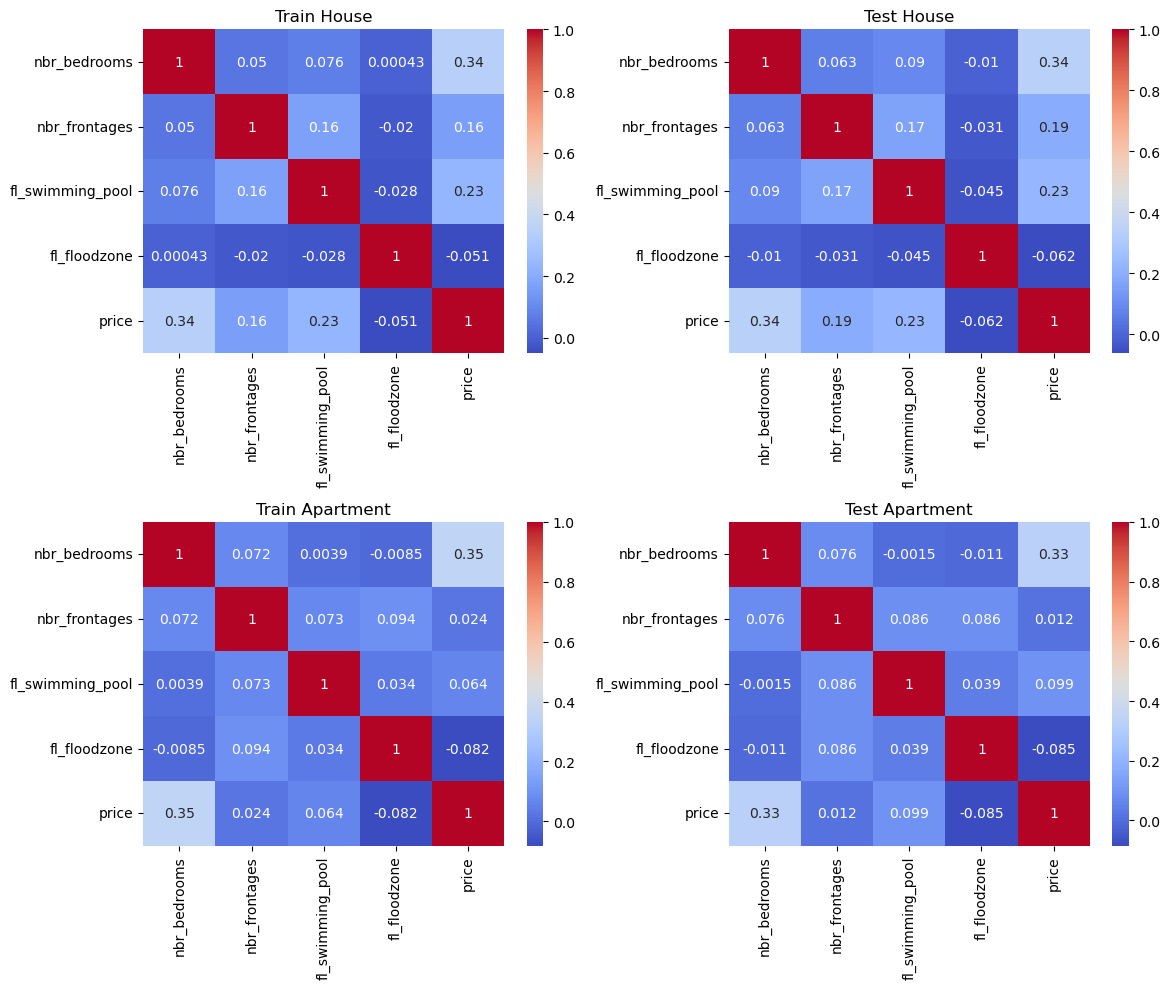

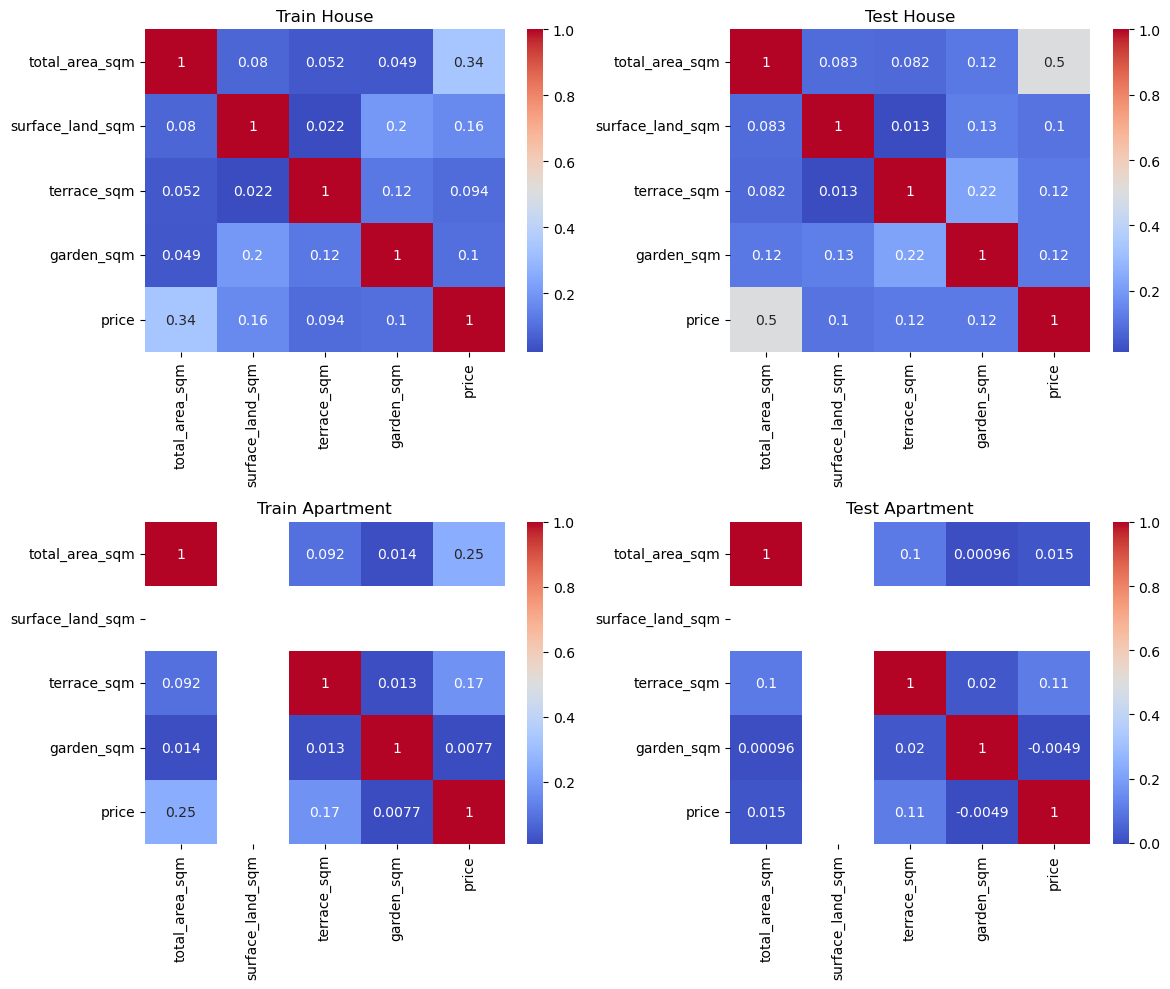

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

def correlation_analysis(train_house, test_house, train_apart, test_apart):
    """
    Perform correlation analysis between size_related_features and price, and between size_features and price.

    Parameters:
    - train_house (DataFrame): Training dataset DataFrame for houses.
    - test_house (DataFrame): Test dataset DataFrame for houses.
    - train_apart (DataFrame): Training dataset DataFrame for apartments.
    - test_apart (DataFrame): Test dataset DataFrame for apartments.

    Returns:
    None. Displays correlation matrices as heatmaps.
    """
    # Size related features and price correlation matrix
    size_related_features = ['nbr_bedrooms', 'nbr_frontages', 'fl_swimming_pool', 'fl_floodzone']
    size_features = ['total_area_sqm', 'surface_land_sqm', 'terrace_sqm', 'garden_sqm']
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    sns.heatmap(train_house[size_related_features + ['price']].corr(), annot=True, cmap='coolwarm', ax=axs[0, 0])
    axs[0, 0].set_title('Train House')
    
    sns.heatmap(test_house[size_related_features + ['price']].corr(), annot=True, cmap='coolwarm', ax=axs[0, 1])
    axs[0, 1].set_title('Test House')
    
    sns.heatmap(train_apart[size_related_features + ['price']].corr(), annot=True, cmap='coolwarm', ax=axs[1, 0])
    axs[1, 0].set_title('Train Apartment')
    
    sns.heatmap(test_apart[size_related_features + ['price']].corr(), annot=True, cmap='coolwarm', ax=axs[1, 1])
    axs[1, 1].set_title('Test Apartment')
    
    plt.tight_layout()
    plt.show()

    # Size features and price correlation matrix
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    sns.heatmap(train_house[size_features + ['price']].corr(), annot=True, cmap='coolwarm', ax=axs[0, 0])
    axs[0, 0].set_title('Train House')
    
    sns.heatmap(test_house[size_features + ['price']].corr(), annot=True, cmap='coolwarm', ax=axs[0, 1])
    axs[0, 1].set_title('Test House')
    
    sns.heatmap(train_apart[size_features + ['price']].corr(), annot=True, cmap='coolwarm', ax=axs[1, 0])
    axs[1, 0].set_title('Train Apartment')
    
    sns.heatmap(test_apart[size_features + ['price']].corr(), annot=True, cmap='coolwarm', ax=axs[1, 1])
    axs[1, 1].set_title('Test Apartment')
    
    plt.tight_layout()
    plt.show()

# Return the function
correlation_analysis(train_house, test_house, train_apart, test_apart)


(XX) Check the correlation beween size features and size-related features 

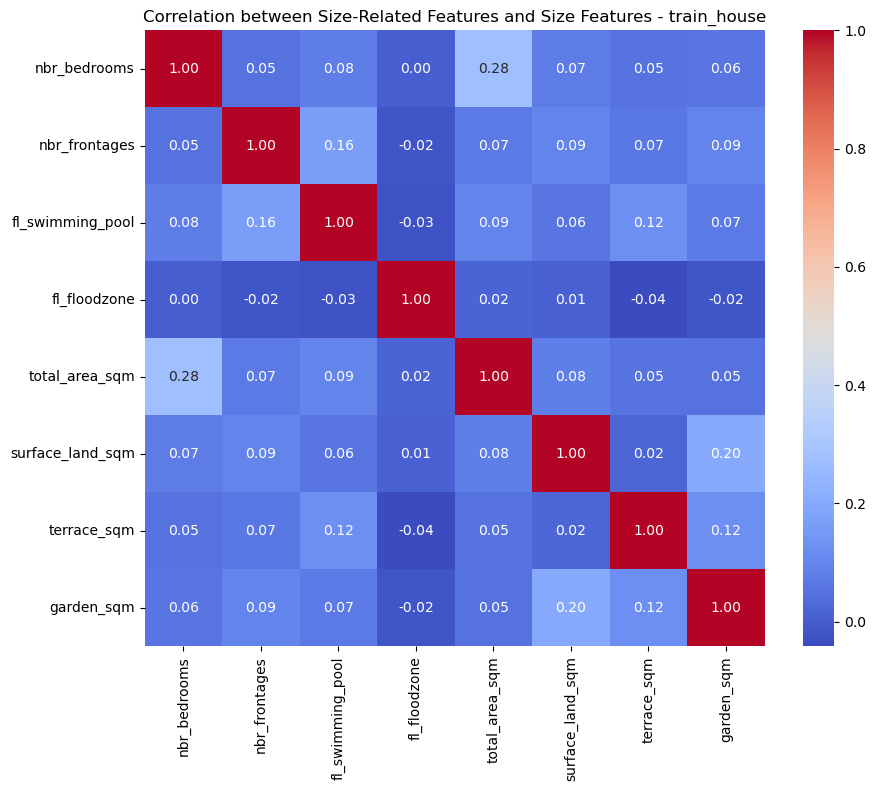

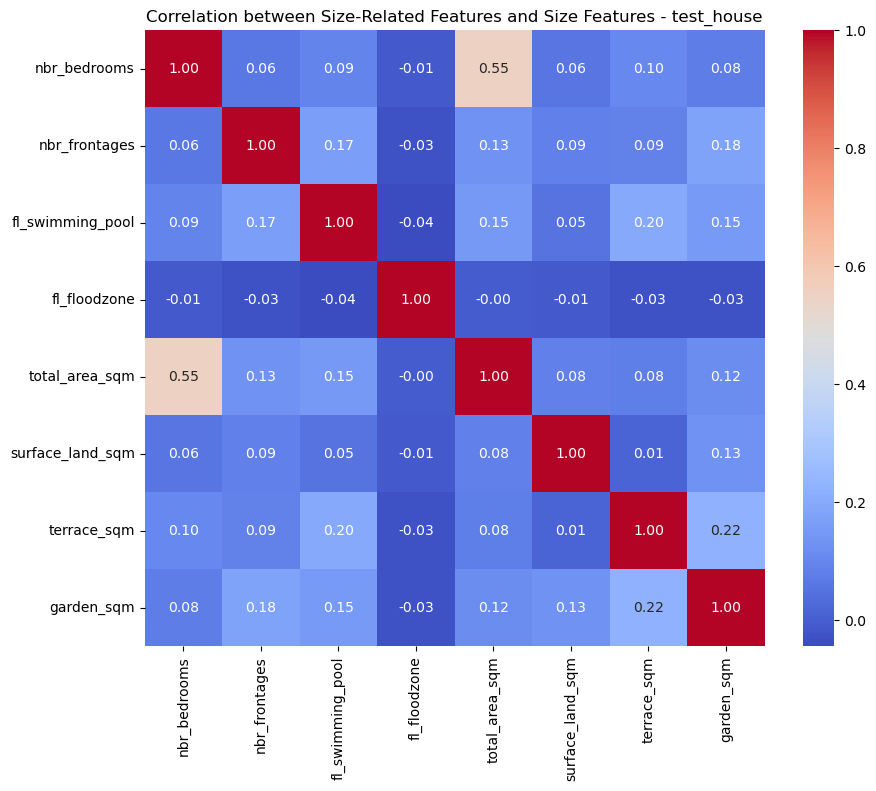

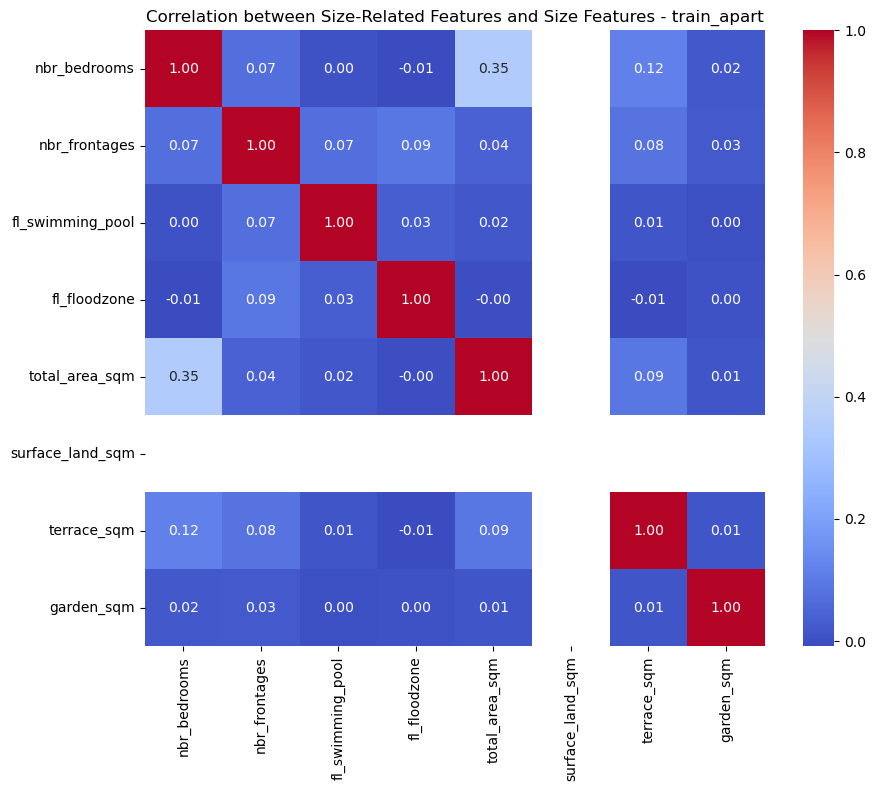

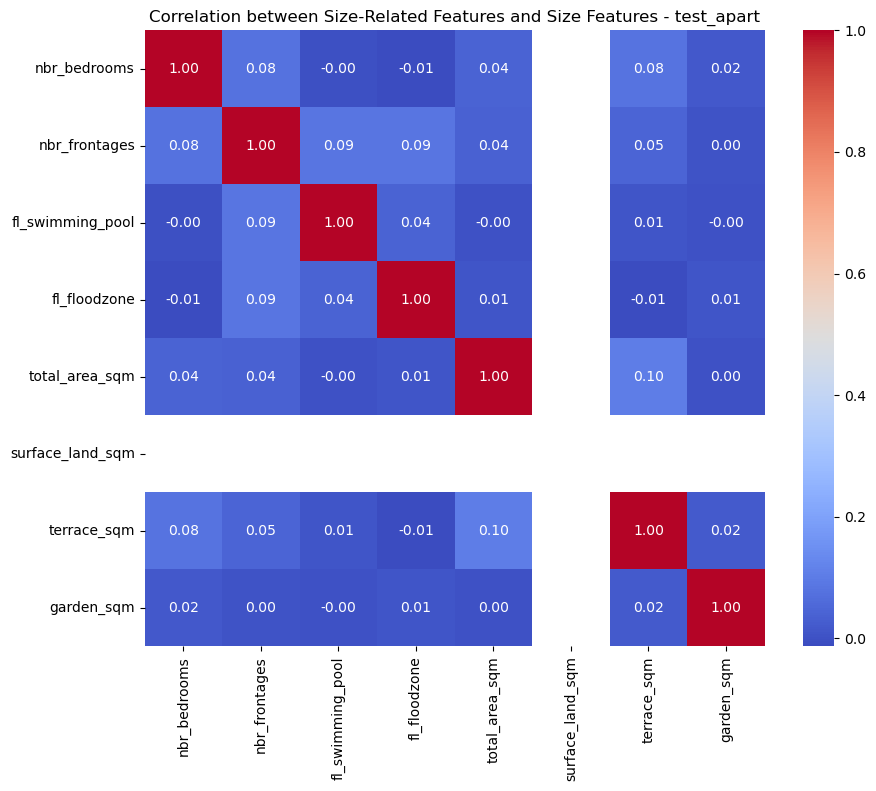

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

def correlation_between_sizes(df_list, size_related_features, size_features):
    """
    Perform correlation analysis between size_related_features and size_features for all the dataframes.

    Parameters:
    - df_list (dict): Dictionary containing DataFrames to process.
    - size_related_features (list of str): List of column names representing size-related features.
    - size_features (list of str): List of column names representing size features.

    Returns:
    None. Displays the correlation matrices as heatmaps for each dataframe.
    """
    for df_type, df in df_list.items():
        # Concatenate the lists of features
        all_features = size_related_features + size_features
        
        # Compute the correlation matrix
        corr_matrix = df[all_features].corr()
        
        # Plot the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title(f'Correlation between Size-Related Features and Size Features - {df_type}')
        plt.show()

# Return the function
# Assuming df_list is a list containing your dataframes
df_dict = {'train_house': train_house, 'test_house': test_house, 'train_apart': train_apart, 'test_apart': test_apart}

# Call the correlation_between_sizes function with the df_dict dictionary
correlation_between_sizes(df_dict, size_related_features, size_features)




(XX) Impute missing total area sqm (total_area_sqm) by (nbr_bedrooms) & Impute missing terrace area (terrace_sqm) if propoerty have terrace (fl_terrace == 1) by total area square ((total_area_sqm)) median and KNN (Nearest Neigborhood) for all dataframes 

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

def impute_missing_values(df_list):
    """
    Impute missing values of 'total_area_sqm' by 'nbr_bedrooms' using median imputation.
    Impute missing values of 'terrace_sqm' by 'total_area_sqm' if 'fl_terrace' == 1 using KNN imputation.

    Parameters:
    - df_list (list of DataFrames): List of DataFrames to process.

    Returns:
    - df_list (list of DataFrames): Updated list of DataFrames with missing values imputed.
    """
    for df in df_list:
        # Median imputation for 'total_area_sqm' by 'nbr_bedrooms'
        imputer_median = SimpleImputer(strategy='median')
        df['total_area_sqm'] = imputer_median.fit_transform(df[['total_area_sqm', 'nbr_bedrooms']])

        # KNN imputation for 'terrace_sqm' by 'total_area_sqm' if 'fl_terrace' == 1
        df['terrace_sqm'] = df.apply(lambda row: row['total_area_sqm'] if row['fl_terrace'] == 1 else row['terrace_sqm'], axis=1)
        imputer_knn = KNNImputer(n_neighbors=5)  # You can adjust the number of neighbors as needed
        df['terrace_sqm'] = imputer_knn.fit_transform(df[['terrace_sqm', 'total_area_sqm']])
        
    return df_list


Before you scale the price follow the steps above scaling code is down

Scale the price variable 

In [14]:
from sklearn.preprocessing import StandardScaler

def scale_price_variable(train_apart, train_house):
    """
    Scale the 'price' variable in the training datasets train_apart and train_house
    using the standardization process and compute summary statistics.
    Parameters:
    - train_apart (DataFrame): Training dataset for apartments.
    - train_house (DataFrame): Training dataset for houses.
    Returns:
    - train_apart_scaled (DataFrame): Scaled training dataset for apartments with 'price' variable standardized.
    - train_house_scaled (DataFrame): Scaled training dataset for houses with 'price' variable standardized.
    - summary_stats_before (DataFrame): Summary statistics of 'price' variable before scaling.
    - summary_stats_after (DataFrame): Summary statistics of 'scaled_price' variable after scaling.
    """

    # Compute summary statistics of 'price' variable before scaling
    summary_stats_before = pd.DataFrame({
        'Mean': [train_apart['price'].mean(), train_house['price'].mean()],
        'Median': [train_apart['price'].median(), train_house['price'].median()],
        'Std Deviation': [train_apart['price'].std(), train_house['price'].std()]
    }, index=['Train Apart', 'Train House'])

    # Create a StandardScaler object
    scaler = StandardScaler()

    # Scale 'price' variable in the training dataset for apartments
    train_apart_scaled = train_apart.copy()  # Make a copy to avoid modifying the original DataFrame
    train_apart_scaled['scaled_price'] = scaler.fit_transform(train_apart[['price']])

    # Scale 'price' variable in the training dataset for houses
    train_house_scaled = train_house.copy()  # Make a copy to avoid modifying the original DataFrame
    train_house_scaled['scaled_price'] = scaler.fit_transform(train_house[['price']])

    # Compute summary statistics of 'scaled_price' variable after scaling
    summary_stats_after = pd.DataFrame({
        'Mean': [train_apart_scaled['scaled_price'].mean(), train_house_scaled['scaled_price'].mean()],
        'Median': [train_apart_scaled['scaled_price'].median(), train_house_scaled['scaled_price'].median()],
        'Std Deviation': [train_apart_scaled['scaled_price'].std(), train_house_scaled['scaled_price'].std()]
    }, index=['Train Apart', 'Train House'])

    return train_apart_scaled, train_house_scaled, summary_stats_before, summary_stats_after

# Print summary statistics before scaling
print("Summary statistics of 'price' variable before scaling:")
print(summary_stats_before)

# Print summary statistics after scaling
print("\nSummary statistics of 'scaled_price' variable after scaling:")
print(summary_stats_after)



Summary statistics of 'price' variable before scaling:


NameError: name 'summary_stats_before' is not defined

Count if all missing in energy 

In [12]:
def energy_missing_all(train_df):
    """
    Count the total number and percentage of missing observations in all specified columns related to energy consumption
    where all columns in the same row have missing values.

    Parameters:
    - train_df (DataFrame): The training dataset DataFrame.

    Returns:
    None. Prints the total count and percentage of missing observations for all specified energy columns.
    """
    energy_cols = ['primary_energy_consumption_sqm', 'epc', 'heating_type', 'fl_double_glazing']

    # Count total missing observations where all energy columns are missing
    total_missing = (train_df[energy_cols].isna().all(axis=1)).sum()
    total_rows = train_df.shape[0]
    total_missing_percentage = (total_missing / total_rows) * 100

    print("Total number and percentage of missing observations in all energy-related columns where all columns are missing:")
    print("Total Missing Observations:", total_missing)
    print("Total Missing Observations Percentage:", total_missing_percentage)

# Example usage:
# Assuming train_apart is your training DataFrame
energy_missing_all(train_apart)


Total number and percentage of missing observations in all energy-related columns where all columns are missing:
Total Missing Observations: 0
Total Missing Observations Percentage: 0.0


Indentify categorical and numeric columns (Not needed because data is transformed)

In [5]:
# Datatype function list of categorical and numeric columns
import pandas as pd

def identify_data_types(df):
    """
    Identify categorical and numeric columns in a DataFrame.

    Parameters:
    - df (DataFrame): The pandas DataFrame to analyze.

    Returns:
    None. Prints the list of categorical and numeric columns.
    """
    categorical_columns = []
    numeric_columns = []

    for column in df.columns:
        if pd.api.types.is_categorical_dtype(df[column]):
            categorical_columns.append(column)
        elif pd.api.types.is_numeric_dtype(df[column]):
            numeric_columns.append(column)

    print("Categorical Columns:", categorical_columns)
    print("Numeric Columns:", numeric_columns)


# Call the function with your DataFrame
identify_data_types(df)


Categorical Columns: []
Numeric Columns: ['id', 'price', 'zip_code', 'latitude', 'longitude', 'construction_year', 'total_area_sqm', 'surface_land_sqm', 'nbr_frontages', 'nbr_bedrooms', 'fl_furnished', 'fl_open_fire', 'fl_terrace', 'terrace_sqm', 'fl_garden', 'garden_sqm', 'fl_swimming_pool', 'fl_floodzone', 'primary_energy_consumption_sqm', 'fl_double_glazing', 'cadastral_income']


/var/folders/fm/44j74rnn4cn95_4v5x1zgpgr0000gn/T/ipykernel_3781/3734452082.py:18: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[column]):


MHZ runningg the regression

In [ ]:
# Load libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import joblib


# Load the CSV file into a DataFrame
df = pd.read_csv('C:\\Users\\afshi\\Documents\\GitHub\\immo-eliza-ml\\data\\properties.csv')

# Define features to use
# I removed "cadastral_income", "surface_land_sqm", "construction_year" because they had  vary high percentag eof null values
# I do not include f1_features because they are not correlated very much based on our analysis in last project
numerical_features = [ "cadastral_income","surface_land_sqm", "total_area_sqm","construction_year", "latitude", "longitude", "garden_sqm", "primary_energy_consumption_sqm",  "nbr_frontages", "nbr_bedrooms", "terrace_sqm"]
fl_features = ["fl_garden", "fl_furnished", "fl_open_fire", "fl_terrace", "fl_swimming_pool", "fl_floodzone", "fl_double_glazing"]

cat_features = ['property_type', 'subproperty_type', 'region', 'province', 'locality', 'zip_code', 'state_building', 'epc', 'heating_type', 'equipped_kitchen']

# Split the data into features and target
X = df[numerical_features + fl_features + cat_features]
y = df["price"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Impute missing values using SimpleImputer on numerical features
imputer = SimpleImputer(strategy="mean")
imputer.fit(X_train[numerical_features])
X_train[numerical_features] = imputer.transform(X_train[numerical_features])
X_test[numerical_features] = imputer.transform(X_test[numerical_features])


# Initialize OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore')
#enc = OneHotEncoder()

# Fit OneHotEncoder to training data
enc.fit(X_train[cat_features])

# Transform categorical features in training and testing data
X_train_cat = enc.transform(X_train[cat_features]).toarray()
X_test_cat = enc.transform(X_test[cat_features]).toarray()


# Concatenate numerical features, encoded categorical features, and f1_features for training and testing data
X_train_processed = np.concatenate([X_train[numerical_features], X_train_cat, X_train[fl_features]], axis=1)
X_test_processed = np.concatenate([X_test[numerical_features], X_test_cat, X_test[fl_features]], axis=1)

# Plot each feature against the target variable

# Plot each feature against the target variable
# List of all feature names
all_features = numerical_features +  cat_features

# Plot each feature against the target variable
#for i, feature_name in enumerate(all_features):
#    plt.figure(figsize=(8, 6))
#    plt.scatter(X_train_processed[:, i], y_train, c='blue', alpha=0.5)
#    plt.xlabel(feature_name)
#    plt.ylabel('Price')
#    plt.title('{} vs Target'.format(feature_name))
#    plt.grid(True)
#    plt.show()

# Debugging dimensions
#print("Shape of X_train_processed:", X_train_processed.shape)
#print("Length of all_features:", len(all_features))

# Calculate correlation coefficients for numerical features
# Calculate correlation coefficients for numerical features
#numerical_correlation = pd.DataFrame(X_train_processed[:, :len(numerical_features)], columns=numerical_features).corrwith(y_train)

# Calculate correlation coefficients for encoded categorical features
#encoded_cat_correlation = pd.DataFrame(X_train_processed[:, len(numerical_features):], columns=enc.get_feature_names_out(cat_features)).corrwith(y_train)

#print("Correlation Coefficients for Numerical Features:")
#print(numerical_correlation)

#print("\nCorrelation Coefficients for Categorical Features:")
#print(encoded_cat_correlation)


# Train the model on the training data
# Train the model on the training data
regressor = LinearRegression()
regressor.fit(X_train_processed, y_train)

# Make predictions
y_train_pred = regressor.predict(X_train_processed)
y_test_pred = regressor.predict(X_test_processed)

# Calculate the scores
train_score = regressor.score(X_train_processed, y_train)
test_score = regressor.score(X_test_processed, y_test)
print(f"Train score is: {train_score}")
print(f"Test score is: {test_score}")

# Visualize the actual vs. predicted prices for training set
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, color='blue', label='Predictions')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='Actuals')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices (Training Set)')
plt.legend()
plt.show()

# Visualize the actual vs. predicted prices for test set
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='blue', label='Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Actuals')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices (Test Set)')
plt.legend()
plt.show()


# Save the trained model
joblib.dump(regressor, 'trained_model.pkl'